In [17]:
import numpy as np
import matplotlib.pyplot as plt

In [66]:
N = 128
M = 2*N + 1
SAMPLE_FREQ = 250
MIN_FREQ = 2 * np.pi * 15 / SAMPLE_FREQ
MAX_FREQ = 2 * np.pi * 30 / SAMPLE_FREQ

In [51]:
def h(n: int) -> float:
    if n == 0:
        return 1/(np.pi) * (MAX_FREQ - MIN_FREQ)
    return 1/(n*np.pi) * (np.sin(MAX_FREQ * n) - np.sin(MIN_FREQ * n))

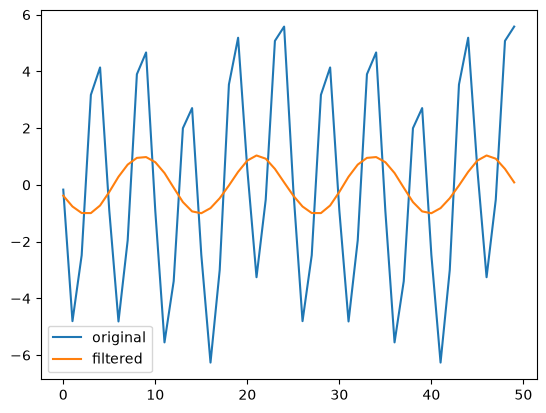

In [67]:
filter_response = np.array(list(map(lambda n: h(n), range(-N, N + 1))))

n = np.arange(0, 1000)
n_samples = 50
signal_freq_hz = 20
x = 5 * np.sin(2 * np.pi * 50 * n / SAMPLE_FREQ + 0.5 * np.pi/2) + \
    np.sin(2 * np.pi * signal_freq_hz * n / SAMPLE_FREQ) + \
    np.sin(2 * np.pi * 10 * n / SAMPLE_FREQ)
y = np.convolve(filter_response, x, "same")
x = x[M:]
y = y[M:]

plt.plot(x[:n_samples], label="original")
plt.plot(y[:n_samples], label="filtered")
plt.legend()

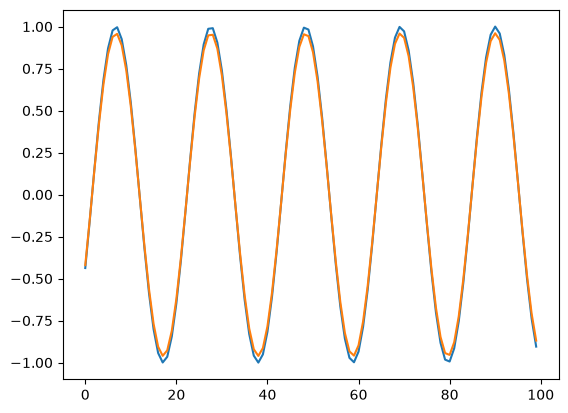